<a href="https://colab.research.google.com/github/Aijamal24/ML_Practice/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ИСХОДНАЯ МАТРИЦА ОШИБОК

                  ПРОГНОЗ
                Нет      Да
ФАКТ Нет        765       85
ФАКТ Да         22        128


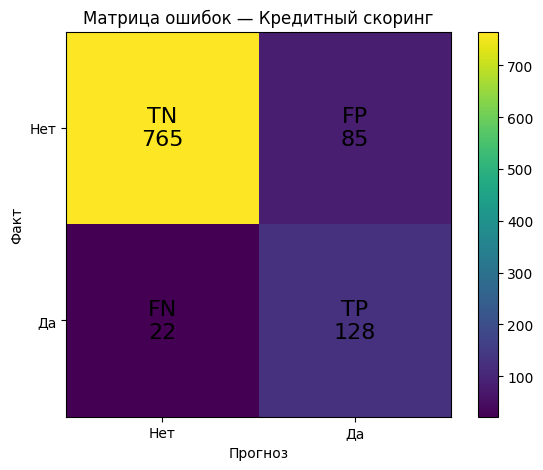

МЕТРИКИ ИСХОДНОЙ МОДЕЛИ

Accuracy: 0.893
Precision: 0.601
Recall: 0.853
Specificity: 0.9
F1: 0.705

МОДЕЛЬ, КОТОРАЯ ВСЕГДА ОТВЕЧАЕТ 'НЕТ'

Accuracy: 0.765

НОВАЯ МАТРИЦА ПОСЛЕ СДВИГА ПОРОГА

                  ПРОГНОЗ
                Нет      Да
ФАКТ Нет        755       95
ФАКТ Да         13        137


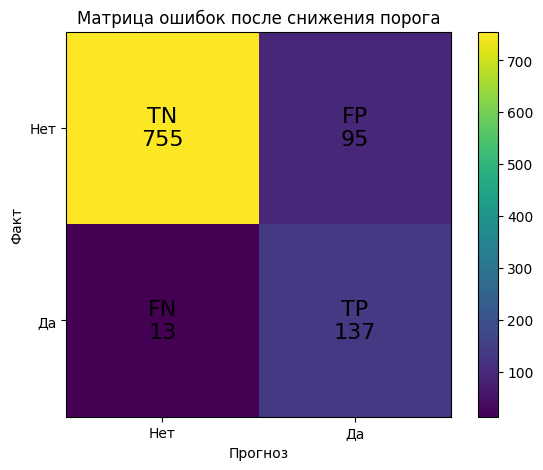

НОВЫЕ МЕТРИКИ ПОСЛЕ СДВИГА ПОРОГА

Accuracy: 0.892
Precision: 0.591
Recall: 0.913
F1: 0.717


In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# ВАРИАНТ 3 — КРЕДИТНЫЙ СКОРИНГ
# Положительный класс: заёмщик допустит дефолт
# ============================================

# Исходная матрица ошибок
TP = 128
FN = 22
FP = 85
TN = 765

# ============================================
# 1. Матрица ошибок 2x2
# ============================================

confusion_matrix = np.array([
    [TN, FP],
    [FN, TP]
])

print("ИСХОДНАЯ МАТРИЦА ОШИБОК")
print()
print("                  ПРОГНОЗ")
print("                Нет      Да")
print("ФАКТ Нет       ", TN, "     ", FP)
print("ФАКТ Да        ", FN, "      ", TP)

# Рисуем матрицу
plt.figure(figsize=(7, 5))

plt.imshow(confusion_matrix)

plt.title("Матрица ошибок — Кредитный скоринг")
plt.xlabel("Прогноз")
plt.ylabel("Факт")

plt.xticks([0, 1], ["Нет", "Да"])
plt.yticks([0, 1], ["Нет", "Да"])

plt.text(0, 0, "TN\n765", ha="center", va="center", fontsize=16)
plt.text(1, 0, "FP\n85", ha="center", va="center", fontsize=16)
plt.text(0, 1, "FN\n22", ha="center", va="center", fontsize=16)
plt.text(1, 1, "TP\n128", ha="center", va="center", fontsize=16)

plt.colorbar()
plt.show()


# ============================================
# 2. Расчёт метрик
# ============================================

total = TP + TN + FP + FN

accuracy = (TP + TN) / total

precision = TP / (TP + FP)

recall = TP / (TP + FN)

specificity = TN / (TN + FP)

f1 = 2 * precision * recall / (precision + recall)

print("МЕТРИКИ ИСХОДНОЙ МОДЕЛИ")
print()
print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("Specificity:", round(specificity, 3))
print("F1:", round(f1, 3))


# ============================================
# 3. Accuracy модели, которая всегда отвечает "нет"
# ============================================

accuracy_always_no = TN / total

print()
print("МОДЕЛЬ, КОТОРАЯ ВСЕГДА ОТВЕЧАЕТ 'НЕТ'")
print()
print("Accuracy:", round(accuracy_always_no, 3))


# ============================================
# 4. Сдвиг порога
# ============================================
# 9 FN -> TP
# 10 TN -> FP

new_TP = TP + 9
new_FN = FN - 9

new_FP = FP + 10
new_TN = TN - 10

print()
print("НОВАЯ МАТРИЦА ПОСЛЕ СДВИГА ПОРОГА")
print()
print("                  ПРОГНОЗ")
print("                Нет      Да")
print("ФАКТ Нет       ", new_TN, "     ", new_FP)
print("ФАКТ Да        ", new_FN, "      ", new_TP)


# Рисуем новую матрицу
new_confusion_matrix = np.array([
    [new_TN, new_FP],
    [new_FN, new_TP]
])

plt.figure(figsize=(7, 5))

plt.imshow(new_confusion_matrix)

plt.title("Матрица ошибок после снижения порога")
plt.xlabel("Прогноз")
plt.ylabel("Факт")

plt.xticks([0, 1], ["Нет", "Да"])
plt.yticks([0, 1], ["Нет", "Да"])

plt.text(0, 0, "TN\n755", ha="center", va="center", fontsize=16)
plt.text(1, 0, "FP\n95", ha="center", va="center", fontsize=16)
plt.text(0, 1, "FN\n13", ha="center", va="center", fontsize=16)
plt.text(1, 1, "TP\n137", ha="center", va="center", fontsize=16)

plt.colorbar()
plt.show()


# ============================================
# 5. Новые метрики
# ============================================

new_precision = new_TP / (new_TP + new_FP)

new_recall = new_TP / (new_TP + new_FN)

new_f1 = 2 * new_precision * new_recall / (new_precision + new_recall)

new_accuracy = (new_TP + new_TN) / total

print("НОВЫЕ МЕТРИКИ ПОСЛЕ СДВИГА ПОРОГА")
print()
print("Accuracy:", round(new_accuracy, 3))
print("Precision:", round(new_precision, 3))
print("Recall:", round(new_recall, 3))
print("F1:", round(new_f1, 3))